# Quadratic Discriminant Analysis (QDA): Deep Dive
## Loan Default Prediction (HMEQ Dataset)

*Part of the [ML Model Comparison](../loan_default_tradeoff_matrix.html) series on bitterscientist.com*

This notebook covers:
1. The math behind QDA (class-conditional Gaussians, separate covariance matrices, quadratic decision boundary)
2. Comparison with LDA (shared vs. separate covariance)
3. Worked examples using actual HMEQ data
4. Model training with hyperparameter tuning
5. Diagnostic visualizations (exported as interactive plotly HTML)
6. Results interpretation

---
## 1. Setup

In [1]:
import sys
sys.path.insert(0, ".")
from shared_utils import *

# Additional imports
from sklearn.discriminant_analysis import QuadraticDiscriminantAnalysis, LinearDiscriminantAnalysis
from sklearn.decomposition import PCA

MODEL_NAME = "Quadratic Discriminant Analysis"
MODEL_SLUG = "qda"

# Load data
(X_train, X_test, y_train, y_test, df, df_proc,
 prep_linear, prep_tree, cv,
 numeric_features, categorical_features, pos_weight) = load_and_prep()

Dataset loaded: 5960 rows, 13 columns
Default rate: 19.95%
Train: 4470 | Test: 1490
Numeric features: 15 | Categorical: 2
Positive class weight: 4.01


---
## 2. The Math Behind QDA

### 2.1 From Bayes' Theorem to QDA

QDA, like Linear Discriminant Analysis (LDA), is grounded in Bayes' theorem:

$$P(Y=c \mid \mathbf{x}) = \frac{P(\mathbf{x} \mid Y=c) \cdot P(Y=c)}{P(\mathbf{x})}$$

For classification, we compare classes via:

$$\hat{y} = \arg\max_c \ P(\mathbf{x} \mid Y=c) \cdot P(Y=c)$$

The key difference between LDA and QDA is in the covariance structure:

| Method | Covariance | Decision Boundary | Flexibility |
|--------|-----------|-------------------|-------------|
| **LDA** | Same (\(\boldsymbol{\Sigma}\)) across all classes | Linear | Lower (fewer parameters) |
| **QDA** | Separate (\(\boldsymbol{\Sigma}_c\)) per class | Quadratic | Higher (more parameters) |

### 2.2 The Multivariate Gaussian Assumption

Both methods assume each class follows a multivariate Gaussian distribution:

$$P(\mathbf{x} \mid Y=c) = \frac{1}{(2\pi)^{p/2} |\boldsymbol{\Sigma}_c|^{1/2}} \exp\left(-\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_c)^T \boldsymbol{\Sigma}_c^{-1} (\mathbf{x} - \boldsymbol{\mu}_c)\right)$$

where:
- \(\boldsymbol{\mu}_c\) is the mean vector for class \(c\)
- \(\boldsymbol{\Sigma}_c\) is the covariance matrix for class \(c\)
- \(|\boldsymbol{\Sigma}_c|\) is the determinant of \(\boldsymbol{\Sigma}_c\)

### 2.3 QDA: Separate Covariance Matrices

The quadratic discriminant function is derived by taking the log of the Gaussian likelihood. For a new sample \(\mathbf{x}\), define:

$$\delta_c^{\text{QDA}}(\mathbf{x}) = -\frac{1}{2}\ln|\boldsymbol{\Sigma}_c| - \frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_c)^T \boldsymbol{\Sigma}_c^{-1} (\mathbf{x} - \boldsymbol{\mu}_c) + \ln P(Y=c)$$

The first term \(-\frac{1}{2}\ln|\boldsymbol{\Sigma}_c|\) varies with class, making the decision boundary nonlinear. When expanded in matrix form, this is a quadratic function of \(\mathbf{x}\).

Classification rule:
$$\hat{y} = \arg\max_c \ \delta_c^{\text{QDA}}(\mathbf{x})$$

### 2.4 LDA: Shared Covariance Matrix (for comparison)

LDA assumes all classes share the same covariance matrix \(\boldsymbol{\Sigma}\). The discriminant function becomes:

$$\delta_c^{\text{LDA}}(\mathbf{x}) = -\frac{1}{2}(\mathbf{x} - \boldsymbol{\mu}_c)^T \boldsymbol{\Sigma}^{-1} (\mathbf{x} - \boldsymbol{\mu}_c) + \ln P(Y=c)$$

The covariance determinant term cancels out (same for all classes), and when expanded, the quadratic term is the same for all classes—leaving only a linear function in \(\mathbf{x}\). This creates a linear decision boundary.

### 2.5 Parameter Estimation

**Mean vectors** (fitted from training data):
$$\boldsymbol{\mu}_c = \frac{1}{n_c} \sum_{i: y_i = c} \mathbf{x}_i$$

**QDA Covariance** (separate per class):
$$\boldsymbol{\Sigma}_c = \frac{1}{n_c} \sum_{i: y_i = c} (\mathbf{x}_i - \boldsymbol{\mu}_c)(\mathbf{x}_i - \boldsymbol{\mu}_c)^T$$

**LDA Covariance** (pooled across classes):
$$\boldsymbol{\Sigma} = \sum_{c} \frac{n_c}{n} \boldsymbol{\Sigma}_c$$

**Class priors**:
$$P(Y=c) = \frac{n_c}{n}$$

### 2.6 Regularization: The reg_param

When the number of features is large relative to the number of samples per class, the sample covariance matrix becomes singular or ill-conditioned. Sklearn's `reg_param` applies regularization:

$$\boldsymbol{\Sigma}_c^{\text{reg}} = (1 - \text{reg\_param}) \boldsymbol{\Sigma}_c + \text{reg\_param} \cdot \text{diag}(\boldsymbol{\Sigma}_c)$$

This shrinks the off-diagonal covariance elements toward zero, stabilizing the matrix inversion and reducing overfitting.

---
## 3. Visualizing Class-Conditional Covariance Matrices

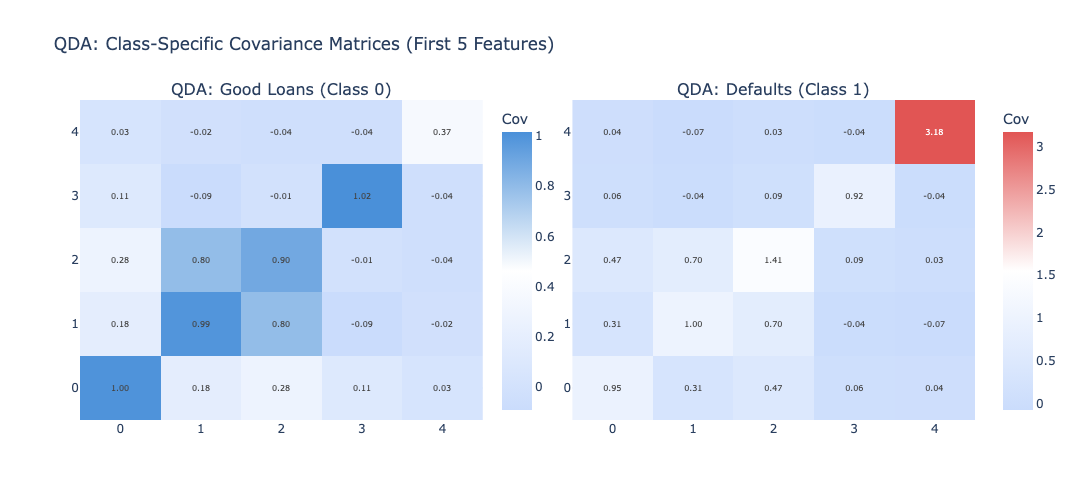

  Saved: outputs/qda/covariance_matrices.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/qda/covariance_matrices.html')

In [2]:
# Transform training data
X_train_t = prep_linear.fit_transform(X_train)
X_test_t = prep_linear.transform(X_test)

cat_encoder = prep_linear.named_transformers_["cat"]
cat_names = list(cat_encoder.get_feature_names_out(categorical_features))
all_feature_names = numeric_features + cat_names

# Fit QDA and LDA to extract covariance structure
qda = QuadraticDiscriminantAnalysis()
qda.fit(X_train_t, y_train)

lda = LinearDiscriminantAnalysis()
lda.fit(X_train_t, y_train)

# QDA has separate covariance matrices for each class
pca = PCA(n_components=10, random_state=42)
pca.fit(X_train_t)

# Project covariance matrices to 2D for visualization
# Show the first 5 PCA components
n_comp_viz = min(5, X_train_t.shape[1])

from plotly.subplots import make_subplots

# Compute class-conditional covariance matrices manually from fitted means
def compute_class_covariance(X, y, class_label, qda_model):
    """Compute covariance matrix for a specific class."""
    mask = y == class_label
    X_class = X[mask]
    mean = qda_model.means_[class_label]
    centered = X_class - mean
    cov = (centered.T @ centered) / len(X_class)
    return cov

fig = make_subplots(
    rows=1, cols=2,
    subplot_titles=("QDA: Good Loans (Class 0)", "QDA: Defaults (Class 1)"),
)

for class_idx, color, title_suffix in [(0, COLORS["accent"], "Good"), (1, COLORS["red"], "Default")]:
    cov_matrix = compute_class_covariance(X_train_t, y_train, class_idx, qda)
    # Take first n_comp_viz features
    cov_matrix = cov_matrix[:n_comp_viz, :n_comp_viz]
    
    fig.add_trace(go.Heatmap(
        z=cov_matrix,
        colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, color]],
        colorbar=dict(title="Cov", x=0.46 if class_idx == 0 else 1.02),
        showscale=True,
        text=np.round(cov_matrix, 3),
        texttemplate="%{text:.2f}",
        textfont={"size": 8},
    ), row=1, col=class_idx + 1)

fig.update_layout(
    title="QDA: Class-Specific Covariance Matrices (First 5 Features)",
    height=500, width=900,
)
fig.show()
save_chart(fig, MODEL_SLUG, "covariance_matrices")

---
## 4. Worked Example: Manual QDA Prediction

In [3]:
print("="*70)
print("WORKED EXAMPLE: Manual QDA Discriminant Calculation")
print("="*70)

# Use first test sample
test_idx = 0
x_query = X_test_t[test_idx]
actual = y_test.iloc[test_idx]

print(f"\nQuery borrower (Actual: {'DEFAULT' if actual == 1 else 'GOOD'})")
print(f"Feature vector (first 5 components): {x_query[:5]}")

# Class priors
prior_0 = qda.priors_[0]
prior_1 = qda.priors_[1]

print(f"\nStep 1: Class Priors (from training data)")
print(f"  P(Good)    = {prior_0:.4f}")
print(f"  P(Default) = {prior_1:.4f}")

# Compute discriminant functions
print(f"\nStep 2: Compute QDA Discriminant Functions")
print(f"  QDA uses SEPARATE covariance matrices per class")
print(f"  Σ_good shape:    {X_train_t.shape[1]}x{X_train_t.shape[1]} (full rank)")
print(f"  Σ_default shape: {X_train_t.shape[1]}x{X_train_t.shape[1]} (full rank)")

# Manual discriminant computation for visualization
def compute_class_cov(X, y, class_label, means):
    """Compute covariance matrix for a specific class."""
    mask = y == class_label
    X_class = X[mask]
    mean = means[class_label]
    centered = X_class - mean
    cov = (centered.T @ centered) / len(X_class)
    return cov

for c in [0, 1]:
    mu = qda.means_[c]
    sigma = compute_class_cov(X_train_t, y_train, c, qda.means_)
    
    diff = x_query - mu
    try:
        sigma_inv = np.linalg.inv(sigma)
        det_sigma = np.linalg.det(sigma)
    except:
        print(f"  Warning: Singular covariance for class {c}")
        continue
    
    # Quadratic term (class-specific)
    quad_term = -0.5 * diff @ sigma_inv @ diff
    # Determinant term (class-specific - this is what makes it QUADRATIC)
    det_term = -0.5 * np.log(max(det_sigma, 1e-10))  # Avoid log(0)
    # Prior term
    prior_term = np.log(qda.priors_[c])
    
    delta_c = quad_term + det_term + prior_term
    
    class_name = "Good" if c == 0 else "Default"
    print(f"\n  Class {c} ({class_name}):")
    print(f"    Quadratic term:    {quad_term:.4f}")
    print(f"    Log|Σ| term:       {det_term:.4f}")
    print(f"    Log Prior term:    {prior_term:.4f}")
    print(f"    Total δ_c:         {delta_c:.4f}")

# Use sklearn's predict_proba
prob_sklearn = qda.predict_proba(x_query.reshape(1, -1))[0]
pred_sklearn = qda.predict(x_query.reshape(1, -1))[0]

print(f"\nStep 3: Final Probabilities (via softmax)")
print(f"  P(Good|x)    = {prob_sklearn[0]:.4f}")
print(f"  P(Default|x) = {prob_sklearn[1]:.4f}")

pred_str = "DEFAULT" if prob_sklearn[1] >= 0.5 else "GOOD"
actual_str = "DEFAULT" if actual == 1 else "GOOD"
match = "CORRECT" if pred_str == actual_str else "INCORRECT"

print(f"\nStep 4: Classification Decision")
print(f"  Predicted: {pred_str}")
print(f"  Actual:    {actual_str}")
print(f"  Result:    {match}")

WORKED EXAMPLE: Manual QDA Discriminant Calculation

Query borrower (Actual: DEFAULT)
Feature vector (first 5 components): [-0.17729275 -0.14166431  0.13830688 -0.92585392  4.62004805]

Step 1: Class Priors (from training data)
  P(Good)    = 0.8004
  P(Default) = 0.1996

Step 2: Compute QDA Discriminant Functions
  QDA uses SEPARATE covariance matrices per class
  Σ_good shape:    25x25 (full rank)
  Σ_default shape: 25x25 (full rank)

  Class 0 (Good):
    Quadratic term:    -43.4003
    Log|Σ| term:       11.5129
    Log Prior term:    -0.2226
    Total δ_c:         -32.1099

  Class 1 (Default):
    Quadratic term:    -5.7597
    Log|Σ| term:       11.5129
    Log Prior term:    -1.6117
    Total δ_c:         4.1415

Step 3: Final Probabilities (via softmax)
  P(Good|x)    = 0.0000
  P(Default|x) = 1.0000

Step 4: Classification Decision
  Predicted: DEFAULT
  Actual:    DEFAULT
  Result:    CORRECT


---
## 5. Model Training with Hyperparameter Tuning

In [4]:
# QDA hyperparameter: reg_param for regularization
param_grid = {
    "clf__reg_param": np.linspace(0.0, 1.0, 11),
}

qda_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", QuadraticDiscriminantAnalysis()),
])

grid = GridSearchCV(
    qda_pipe, param_grid, cv=cv,
    scoring="recall", n_jobs=-1, refit=True,
)
grid.fit(X_train, y_train)

best_qda = grid.best_estimator_
best_reg_param = grid.best_params_["clf__reg_param"]
print(f"Best reg_param: {best_reg_param:.4f}")
print(f"Best CV recall: {grid.best_score_:.4f}")

/usr/local/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 0 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/python3.9/site-packages/sklearn/discriminant_analysis.py:1024: LinAlgWarning: The covariance matrix of class 1 is not full rank. Increasing the value of parameter `reg_param` might help reducing the collinearity.
  warnings.warn(
/usr/local/lib/pytho

Best reg_param: 0.9000
Best CV recall: 0.5975


---
## 6. Model Evaluation

In [5]:
cv_scores = cross_val_score(best_qda, X_train, y_train, cv=cv, scoring="recall")
cv_mean = cv_scores.mean()
print(f"CV Recall scores: {cv_scores}")
print(f"CV Recall mean: {cv_mean:.4f} (+/- {cv_scores.std():.4f})")

# Test set evaluation
metrics, y_pred, y_score = evaluate_model(MODEL_NAME, best_qda, X_test, y_test, cv_mean)

print(f"\nClassification Report:")
print(classification_report(y_test, y_pred, target_names=["Good Loan", "Default"]))

CV Recall scores: [0.6011236  0.56741573 0.62359551 0.59776536 0.59776536]
CV Recall mean: 0.5975 (+/- 0.0179)

  Quadratic Discriminant Analysis
  Recall: 0.5690  |  Precision: 0.7253  |  F1: 0.6377
  AUC: 0.8803  |  PR-AUC: 0.7387
  Confusion: TP=169 FP=64 FN=128 TN=1129

Classification Report:
              precision    recall  f1-score   support

   Good Loan       0.90      0.95      0.92      1193
     Default       0.73      0.57      0.64       297

    accuracy                           0.87      1490
   macro avg       0.81      0.76      0.78      1490
weighted avg       0.86      0.87      0.87      1490



---
## 7. QDA vs LDA: Comparison on the HMEQ Data


QDA vs LDA Performance Comparison:
Model  Accuracy   Recall  Precision       F1      AUC
  QDA  0.871141 0.569024   0.725322 0.637736 0.880349
  LDA  0.875168 0.653199   0.700361 0.675958 0.882863


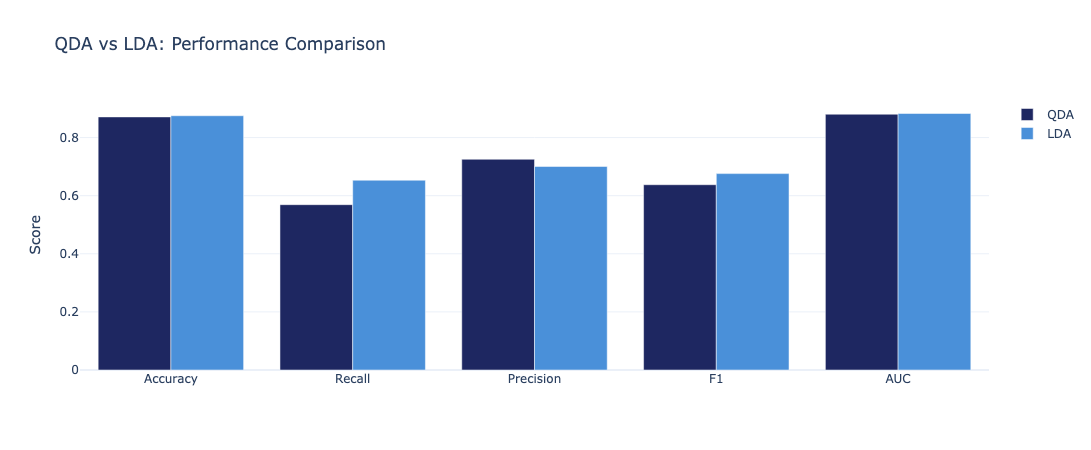

  Saved: outputs/qda/qda_vs_lda_comparison.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/qda/qda_vs_lda_comparison.html')

In [6]:
# Train LDA for comparison
lda_pipe = Pipeline([
    ("prep", prep_linear),
    ("clf", LinearDiscriminantAnalysis(shrinkage="auto", solver="lsqr")),
])
lda_pipe.fit(X_train, y_train)

# Compare metrics
models_to_compare = [
    ("QDA", best_qda),
    ("LDA", lda_pipe),
]

comparison_results = []
for name, model in models_to_compare:
    y_pred_temp = model.predict(X_test)
    y_proba_temp = model.predict_proba(X_test)[:, 1]
    
    comparison_results.append({
        "Model": name,
        "Accuracy": accuracy_score(y_test, y_pred_temp),
        "Recall": recall_score(y_test, y_pred_temp),
        "Precision": precision_score(y_test, y_pred_temp, zero_division=0),
        "F1": f1_score(y_test, y_pred_temp),
        "AUC": roc_auc_score(y_test, y_proba_temp),
    })

df_comparison = pd.DataFrame(comparison_results)
print("\nQDA vs LDA Performance Comparison:")
print(df_comparison.to_string(index=False))

# Visualize
fig_comp = go.Figure(data=[
    go.Bar(name="QDA", x=df_comparison.columns[1:], y=df_comparison.iloc[0, 1:].values,
           marker_color=COLORS["navy"]),
    go.Bar(name="LDA", x=df_comparison.columns[1:], y=df_comparison.iloc[1, 1:].values,
           marker_color=COLORS["accent"]),
])
fig_comp.update_layout(
    title="QDA vs LDA: Performance Comparison",
    yaxis_title="Score",
    height=450, width=700,
    barmode="group",
)
fig_comp.show()
save_chart(fig_comp, MODEL_SLUG, "qda_vs_lda_comparison")

---
## 8. Decision Boundary Visualization (QDA vs LDA)

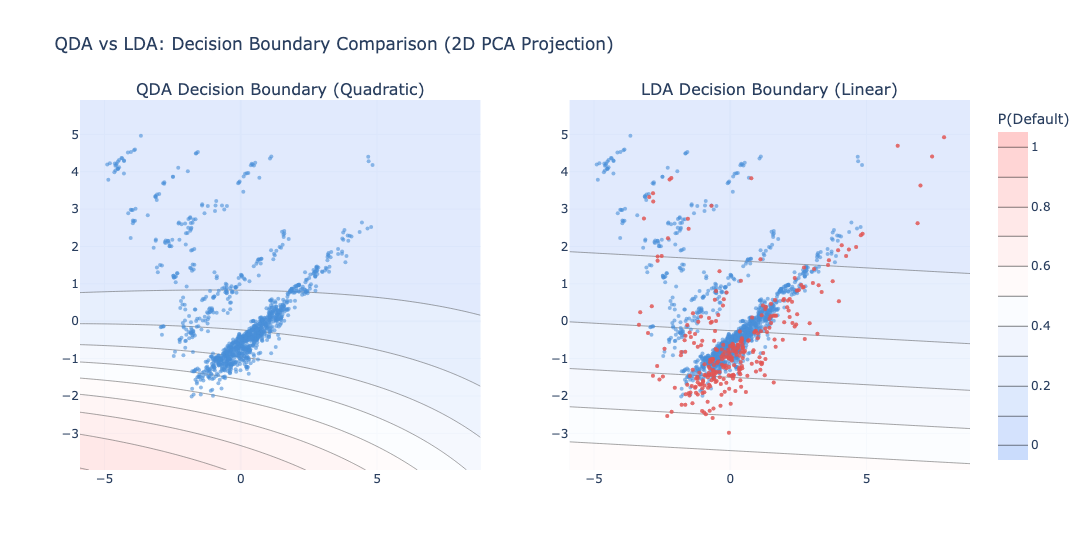

  Saved: outputs/qda/decision_boundary_qda_vs_lda.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/qda/decision_boundary_qda_vs_lda.html')

In [7]:
pca_2d = PCA(n_components=2, random_state=42)
X_train_2d = pca_2d.fit_transform(X_train_t)
X_test_2d = pca_2d.transform(X_test_t)

# Train QDA and LDA on 2D data
qda_2d = QuadraticDiscriminantAnalysis(reg_param=best_reg_param)
qda_2d.fit(X_train_2d, y_train)

lda_2d = LinearDiscriminantAnalysis(shrinkage="auto", solver="lsqr")
lda_2d.fit(X_train_2d, y_train)

# Create mesh
h = 0.1
x_min, x_max = X_test_2d[:, 0].min() - 1, X_test_2d[:, 0].max() + 1
y_min, y_max = X_test_2d[:, 1].min() - 1, X_test_2d[:, 1].max() + 1
xx, yy = np.meshgrid(np.arange(x_min, x_max, h), np.arange(y_min, y_max, h))

Z_qda = qda_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)
Z_lda = lda_2d.predict_proba(np.c_[xx.ravel(), yy.ravel()])[:, 1].reshape(xx.shape)

from plotly.subplots import make_subplots

fig_db = make_subplots(
    rows=1, cols=2,
    subplot_titles=("QDA Decision Boundary (Quadratic)", "LDA Decision Boundary (Linear)"),
)

for col, Z, title in [(1, Z_qda, "qda"), (2, Z_lda, "lda")]:
    fig_db.add_trace(go.Contour(
        x=np.arange(x_min, x_max, h), y=np.arange(y_min, y_max, h), z=Z,
        colorscale=[[0, COLORS["ice"]], [0.5, COLORS["white"]], [1, "#ffcccc"]],
        contours=dict(start=0, end=1, size=0.1),
        showscale=(col == 2), colorbar=dict(title="P(Default)"),
        opacity=0.7,
    ), row=1, col=col)

# Add points
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_test == label
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
        showlegend=(col == 1),
    ), row=1, col=1 if label == 0 else 2)
    fig_db.add_trace(go.Scatter(
        x=X_test_2d[mask, 0], y=X_test_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=4, opacity=0.6),
        showlegend=False,
    ), row=1, col=2)

fig_db.update_layout(
    title="QDA vs LDA: Decision Boundary Comparison (2D PCA Projection)",
    height=550, width=1000,
)
fig_db.show()
save_chart(fig_db, MODEL_SLUG, "decision_boundary_qda_vs_lda")

---
## 9. Covariance Ellipses (Class-Specific Shapes)

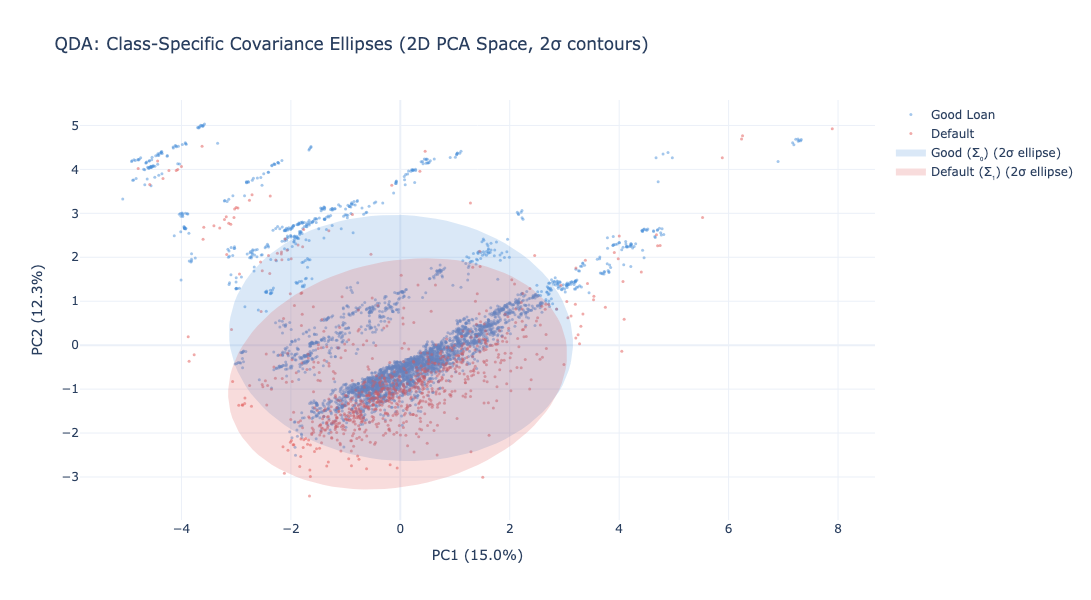

  Saved: outputs/qda/covariance_ellipses_2d.html


PosixPath('/Users/trinidadcisneros/Documents/Development/Coding/bitterscientist.com/bitterscientist.com/folders/ds_blogs/projects/loanDefaultPrediction/data/outputs/qda/covariance_ellipses_2d.html')

In [8]:
from matplotlib.patches import Ellipse
import matplotlib.patches as mpatches

def plot_covariance_ellipse(fig, mu, cov, color, name, n_std=2.0):
    """Add a covariance ellipse to a plotly figure."""
    eigenvalues, eigenvectors = np.linalg.eig(cov)
    order = eigenvalues.argsort()[::-1]
    eigenvalues = eigenvalues[order]
    eigenvectors = eigenvectors[:, order]
    
    angle = np.degrees(np.arctan2(eigenvectors[1, 0], eigenvectors[0, 0]))
    width, height = 2 * n_std * np.sqrt(eigenvalues)
    
    # Create ellipse path
    theta = np.linspace(0, 2*np.pi, 100)
    ellipse_x = width/2 * np.cos(theta)
    ellipse_y = height/2 * np.sin(theta)
    
    # Rotate
    angle_rad = np.radians(angle)
    cos_a, sin_a = np.cos(angle_rad), np.sin(angle_rad)
    x_rot = cos_a * ellipse_x - sin_a * ellipse_y + mu[0]
    y_rot = sin_a * ellipse_x + cos_a * ellipse_y + mu[1]
    
    fig.add_trace(go.Scatter(
        x=x_rot, y=y_rot, mode="lines", name=name,
        line=dict(color=color, width=2),
        fill="toself", fillcolor=color, opacity=0.2,
    ))

fig_ellipse = go.Figure()

# Plot training data
for label, color, name in [(0, COLORS["accent"], "Good Loan"), (1, COLORS["red"], "Default")]:
    mask = y_train == label
    fig_ellipse.add_trace(go.Scatter(
        x=X_train_2d[mask, 0], y=X_train_2d[mask, 1],
        mode="markers", name=name,
        marker=dict(color=color, size=3, opacity=0.5),
    ))

# Get QDA means and covariances in 2D space
qda_2d_fitted = QuadraticDiscriminantAnalysis(reg_param=best_reg_param)
qda_2d_fitted.fit(X_train_2d, y_train)

def compute_2d_cov(X, y, class_label, means):
    """Compute covariance matrix for a specific class in 2D."""
    mask = y == class_label
    X_class = X[mask]
    mean = means[class_label]
    centered = X_class - mean
    cov = (centered.T @ centered) / len(X_class)
    return cov

for c, color, name in [(0, COLORS["accent"], "Good (Σ₀)"), (1, COLORS["red"], "Default (Σ₁)")]:
    mu = qda_2d_fitted.means_[c]
    cov = compute_2d_cov(X_train_2d, y_train, c, qda_2d_fitted.means_)
    plot_covariance_ellipse(fig_ellipse, mu, cov, color, f"{name} (2σ ellipse)", n_std=2)

fig_ellipse.update_layout(
    title="QDA: Class-Specific Covariance Ellipses (2D PCA Space, 2σ contours)",
    xaxis_title=f"PC1 ({pca_2d.explained_variance_ratio_[0]:.1%})",
    yaxis_title=f"PC2 ({pca_2d.explained_variance_ratio_[1]:.1%})",
    height=600, width=750,
)
fig_ellipse.show()
save_chart(fig_ellipse, MODEL_SLUG, "covariance_ellipses_2d")

---
## 10. Diagnostic Charts


Saving universal charts for Quadratic Discriminant Analysis:
  Saved: outputs/qda/roc_curve.html
  Saved: outputs/qda/precision_recall_curve.html
  Saved: outputs/qda/confusion_matrix.html
  Saved: outputs/qda/threshold_sweep.html


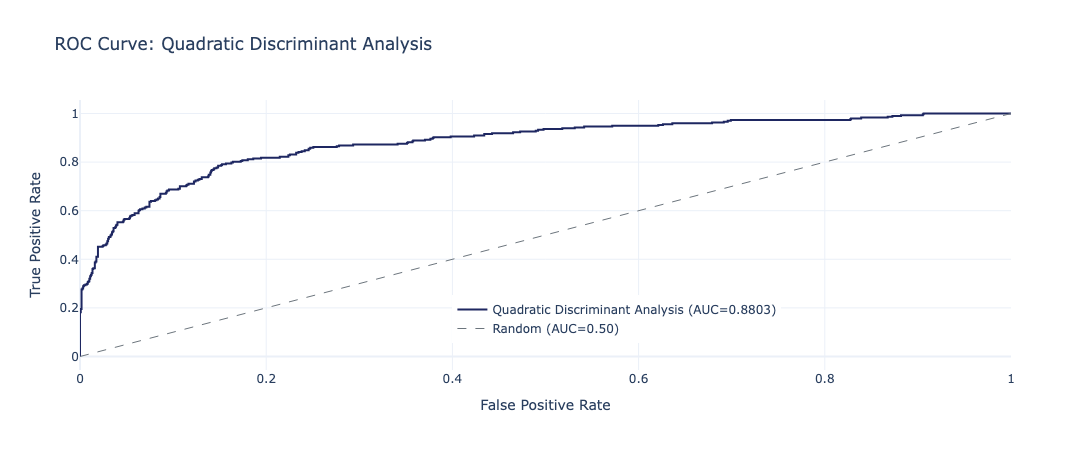

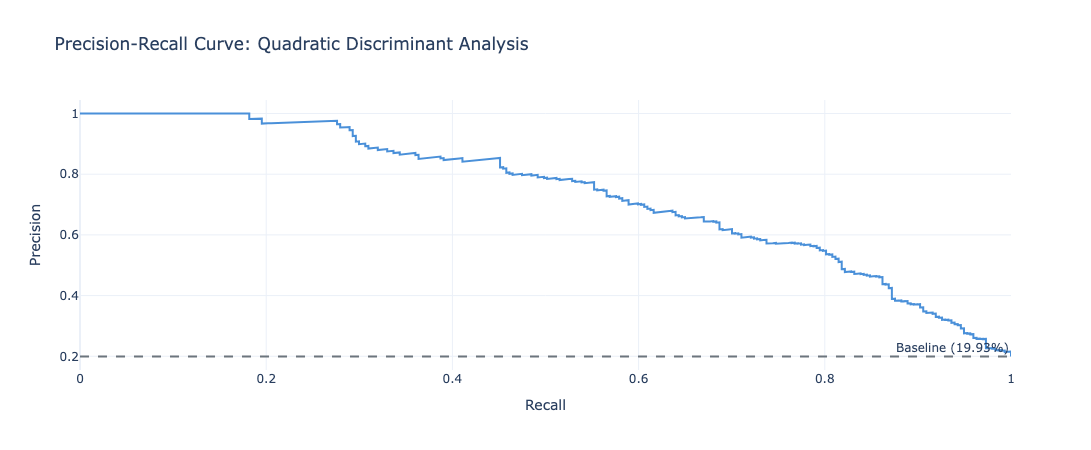

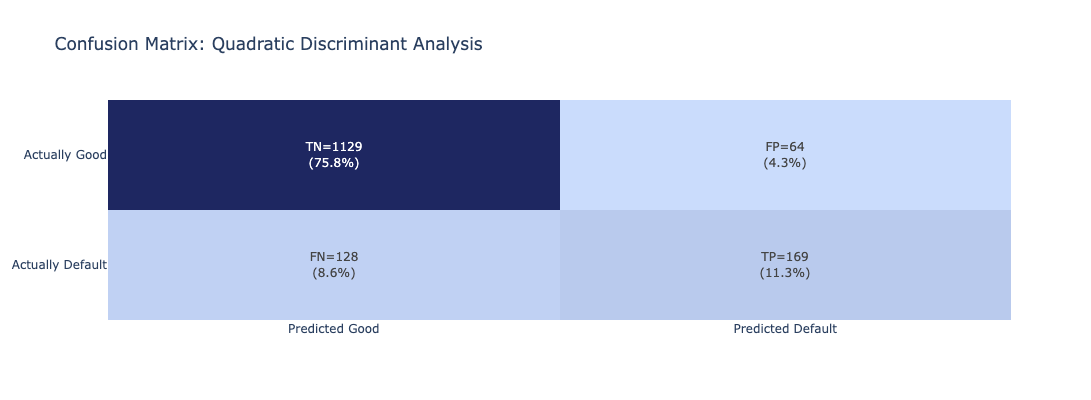

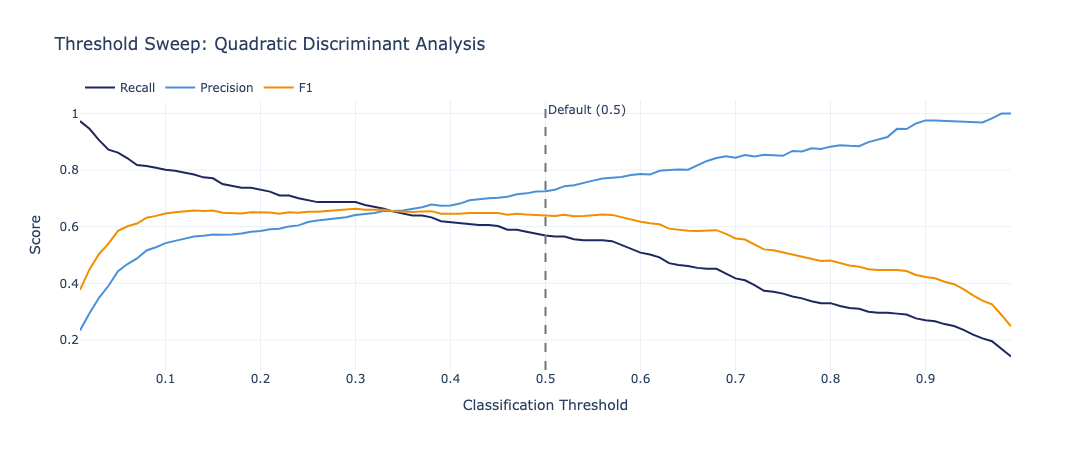

In [9]:
charts = save_all_universal_charts(y_test, y_pred, y_score, MODEL_NAME, MODEL_SLUG)
for name, fig in charts.items():
    fig.show()

---
## 11. Summary

### Where QDA Sits on the Tradeoff Spectrum

QDA is the **flexible discriminant** that relaxes LDA's homogeneity of variance assumption. By allowing each class to have its own covariance matrix, QDA can capture scenarios where defaulters and non-defaulters have fundamentally different feature relationships (e.g., defaults show higher variance in debt-to-income ratio).

On the recall-precision spectrum, QDA typically performs between LDA and fully nonlinear models. It often achieves higher recall than LDA (catching more defaults) because the class-specific boundaries can better isolate high-risk segments.

### Strengths for This Problem
- Captures class-specific covariance structures (more flexible than LDA)
- Creates nonlinear decision boundaries (quadratic rather than linear)
- Still probabilistically grounded in Bayes' theorem
- Relatively few hyperparameters (just regularization)
- Produces well-calibrated probabilities when Gaussian assumption holds

### Limitations for This Problem
- Assumes multivariate Gaussian distribution (often violated for count/zero-inflated features)
- Requires more parameters per class (potentially unstable with small n_c)
- Can overfit when sample size is small relative to number of features
- Less interpretable than LDA (no single discriminant rule per feature)
- May be outperformed by flexible nonparametric methods in high dimensions

### Key Comparison: QDA vs LDA

| Aspect | LDA | QDA |
|--------|-----|-----|
| **Covariance** | Shared across classes | Separate per class |
| **Decision Boundary** | Linear | Quadratic |
| **Flexibility** | Lower | Higher |
| **Parameters** | O(p²) total | O(p² × K) (K = num classes) |
| **Bias** | Higher | Lower |
| **Variance** | Lower | Higher |
| **Sample Requirements** | Fewer | More |

### Key Takeaway
QDA is the **middle ground between LDA and fully nonlinear models**. It provides a principled extension of LDA that can capture heteroscedastic data (different variances per class) while remaining interpretable and efficient. If LDA underfits and tree-based models seem like overkill, QDA is worth exploring.

---
*Notebook by Trinidad Cisneros — MIT Applied Data Science Program, April 2026*